# 02 — EDA: UWHVF Dataset

Explore the University of Washington Humphrey Visual Field dataset.

**Goal**: Understand the data structure, distribution of MD/VFI, progression rates, and data quality before modeling.

In [1]:
import sys
sys.path.insert(0, "..")

import json
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

UWHVF_DIR = Path("../data/raw/uwhvf")
REPORTS_DIR = Path("../reports")
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("UWHVF dir exists:", UWHVF_DIR.exists())

UWHVF dir exists: True


## 1. Load Raw Data

In [2]:
# UWHVF: canonical bundle is alldata.json with top-level pts/eyes/hvfs/coords/data.
# Do not glob-merge every *.json — schema.json becomes a bogus second row with $schema, properties, …


def _flatten_uwhvf_bundle(data: dict) -> list[dict]:
    """One row per (patient, eye, visit) from the `data` object."""
    patients = data.get("data")
    if not isinstance(patients, dict):
        return []
    rows: list[dict] = []
    for pid_str, patient in patients.items():
        if not isinstance(patient, dict):
            continue
        gender = patient.get("gender")
        year_first = patient.get("year")
        for eye in ("L", "R"):
            visits = patient.get(eye)
            if not isinstance(visits, list):
                continue
            for visit_idx, visit in enumerate(visits):
                if not isinstance(visit, dict):
                    continue
                rows.append(
                    {
                        "patient_id": str(pid_str),
                        "eye": eye,
                        "visit_index": visit_idx,
                        "gender": gender,
                        "year_first_vf": year_first,
                        "age": visit.get("age"),
                        "hvf": visit.get("hvf"),
                        "hvf_seq": visit.get("hvf_seq"),
                        "td": visit.get("td"),
                        "td_seq": visit.get("td_seq"),
                    }
                )
    return rows


if (UWHVF_DIR / "alldata.json").exists():
    json_paths = [UWHVF_DIR / "alldata.json"]
else:
    json_paths = sorted(
        p
        for p in UWHVF_DIR.rglob("*.json")
        if p.name.lower() != "schema.json" and not p.name.startswith(".")
    )

print(f"JSON files to load: {len(json_paths)}")
all_records: list[dict] = []
for jf in json_paths:
    with open(jf) as f:
        data = json.load(f)
    if isinstance(data, list):
        all_records.extend(data)
        print(f"  + {jf.name}: {len(data):,} list items")
    elif isinstance(data, dict):
        if "$schema" in data and "properties" in data:
            print(f"  skip schema-like file: {jf}")
            continue
        if isinstance(data.get("data"), dict):
            flat = _flatten_uwhvf_bundle(data)
            all_records.extend(flat)
            print(f"  + {jf.name}: {len(flat):,} visits (flattened)")
        else:
            all_records.append(data)
            print(f"  + {jf.name}: 1 dict row (no `data` key — not standard UWHVF)")

print(f"Total rows: {len(all_records):,}")
if all_records:
    print("Sample keys:", list(all_records[0].keys()))

JSON files to load: 1
  + alldata.json: 28,943 visits (flattened)
Total rows: 28,943
Sample keys: ['patient_id', 'eye', 'visit_index', 'gender', 'year_first_vf', 'age', 'hvf', 'hvf_seq', 'td', 'td_seq']


In [3]:
# Convert to Polars DataFrame
if all_records:
    df = pl.DataFrame(all_records)
    # No instrument MD/VFI in UWHVF — add EDA-only proxies from TD (100 = untested).
    if "td_seq" in df.columns:
        df = df.with_columns(
            pl.col("td_seq")
            .list.eval(pl.element().filter(pl.element() != 100.0).mean())
            .list.first()
            .alias("md_proxy")
        )
        # Rough 0–100 scale for plots only; not Zeiss VFI.
        df = df.with_columns(
            (pl.lit(100.0) + pl.col("md_proxy") * 2.0).clip(0.0, 100.0).alias("vfi_proxy")
        )
    print(f"Shape: {df.shape}")
    print(df.head(3))
else:
    print("No records loaded — run 01_dataset_download.ipynb first")
    # Create synthetic demo data for exploration
    np.random.seed(42)
    n = 500
    df = pl.DataFrame({
        "patient_id": [f"P{i:04d}" for i in range(n)],
        "md": np.random.normal(-5.0, 4.0, n).clip(-30, 0),
        "vfi": np.random.normal(85.0, 15.0, n).clip(0, 100),
        "age": np.random.normal(65, 10, n).clip(40, 90),
        "fp_rate": np.random.uniform(0, 0.4, n),
        "fl_rate": np.random.uniform(0, 0.3, n),
    })
    print("Using synthetic demo data")

Shape: (28943, 12)
shape: (3, 12)
┌────────────┬─────┬─────────────┬────────┬───┬──────────────┬─────────────┬───────────┬───────────┐
│ patient_id ┆ eye ┆ visit_index ┆ gender ┆ … ┆ td           ┆ td_seq      ┆ md_proxy  ┆ vfi_proxy │
│ ---        ┆ --- ┆ ---         ┆ ---    ┆   ┆ ---          ┆ ---         ┆ ---       ┆ ---       │
│ str        ┆ str ┆ i64         ┆ str    ┆   ┆ list[list[f6 ┆ list[f64]   ┆ f64       ┆ f64       │
│            ┆     ┆             ┆        ┆   ┆ 4]]          ┆             ┆           ┆           │
╞════════════╪═════╪═════════════╪════════╪═══╪══════════════╪═════════════╪═══════════╪═══════════╡
│ 647        ┆ L   ┆ 0           ┆ F      ┆ … ┆ [[100.0,     ┆ [-6.02,     ┆ -4.056296 ┆ 91.887407 │
│            ┆     ┆             ┆        ┆   ┆ 100.0, …     ┆ -1.83, …    ┆           ┆           │
│            ┆     ┆             ┆        ┆   ┆ 100.0],      ┆ -4.72]      ┆           ┆           │
│            ┆     ┆             ┆        ┆   ┆ [100…    

## 2. Data Quality

In [4]:
print("=== Missing Values ===")
for col in df.columns:
    n_null = df[col].null_count()
    if n_null > 0:
        print(f"  {col}: {n_null} ({n_null/len(df)*100:.1f}%)")

print("\n=== Data Types ===")
print(df.dtypes)

=== Missing Values ===

=== Data Types ===
[String, String, Int64, String, Int64, Float64, List(List(Float64)), List(Float64), List(List(Float64)), List(Float64), Float64, Float64]


In [5]:
# Reliability (FP / fixation loss): UWHVF alldata has none; synthetic demo adds fp_rate / fl_rate.
_exact = ("false_positive_rate", "fp_rate", "fixation_loss_rate", "fl_rate")
reliability_cols = [c for c in _exact if c in df.columns]
if not reliability_cols:
    _norm = lambda s: s.lower().replace("-", "_").replace(" ", "_")
    reliability_cols = [c for c in df.columns if _norm(c) in _exact]

fp_col = next((c for c in reliability_cols if "fp" in c.lower() or "false" in c.lower()), None)
if fp_col:
    if reliability_cols:
        print("Reliability columns:", reliability_cols)
    reliable_pct = (df[fp_col] <= 0.33).mean() * 100
    print(f"Reliable tests (FP≤33%): {reliable_pct:.1f}%")
elif reliability_cols:
    print("Reliability columns:", reliability_cols, "(no FP column — skipping FP≤33% rule)")
else:
    print("Reliability (FP/FL): skipped — not in UWHVF export.")

Reliability (FP/FL): skipped — not in UWHVF export.


## 3. MD and VFI Distributions

In [6]:
md_col  = next((c for c in df.columns if "md" in c.lower()), None)
vfi_col = next((c for c in df.columns if "vfi" in c.lower()), None)
print(f"MD column: {md_col} | VFI column: {vfi_col}")
if md_col and str(md_col).endswith("_proxy"):
    print("(EDA proxies from mean TD — not Zeiss instrument MD/VFI.)")

if md_col:
    md = df[md_col].drop_nulls().to_numpy()
    print(f"\nMD — mean: {md.mean():.2f} dB | std: {md.std():.2f} | range: [{md.min():.1f}, {md.max():.1f}]")

if vfi_col:
    vfi = df[vfi_col].drop_nulls().to_numpy()
    print(f"VFI — mean: {vfi.mean():.1f}% | std: {vfi.std():.1f} | range: [{vfi.min():.0f}, {vfi.max():.0f}]")

MD column: md_proxy | VFI column: vfi_proxy
(EDA proxies from mean TD — not Zeiss instrument MD/VFI.)

MD — mean: -6.10 dB | std: 6.13 | range: [-31.7, 19.3]
VFI — mean: 87.7% | std: 12.1 | range: [37, 100]


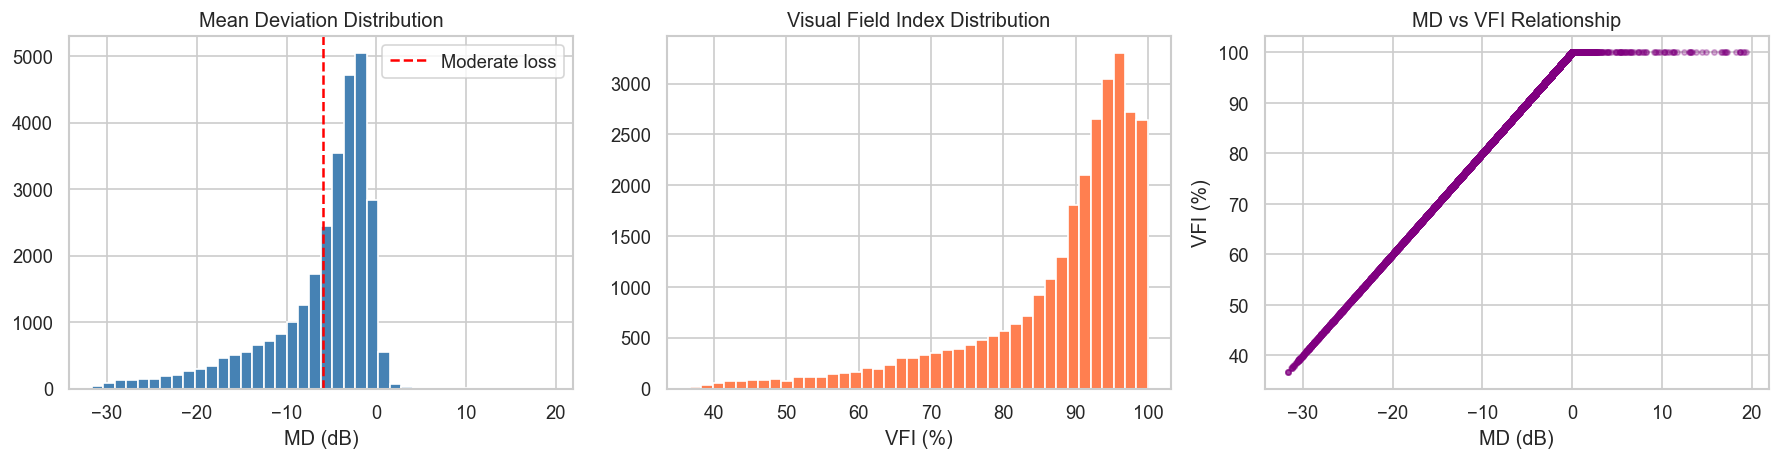

Saved to reports/eda_uwhvf_distributions.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

if md_col:
    axes[0].hist(df[md_col].drop_nulls().to_numpy(), bins=40, color="steelblue", edgecolor="white")
    axes[0].axvline(-6, color="red", ls="--", label="Moderate loss")
    axes[0].set_xlabel("MD (dB)"); axes[0].set_title("Mean Deviation Distribution")
    axes[0].legend()

if vfi_col:
    axes[1].hist(df[vfi_col].drop_nulls().to_numpy(), bins=40, color="coral", edgecolor="white")
    axes[1].set_xlabel("VFI (%)"); axes[1].set_title("Visual Field Index Distribution")

if md_col and vfi_col:
    axes[2].scatter(df[md_col].to_numpy(), df[vfi_col].to_numpy(), alpha=0.3, s=10, color="purple")
    axes[2].set_xlabel("MD (dB)"); axes[2].set_ylabel("VFI (%)")
    axes[2].set_title("MD vs VFI Relationship")

plt.tight_layout()
plt.savefig("../reports/eda_uwhvf_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to reports/eda_uwhvf_distributions.png")

## 4. Longitudinal Analysis — VF Progression Rates

Patient ID col: patient_id | Date col: visit_index

Patients: 3,871
Visits/patient: mean=7.5, median=6, max=38


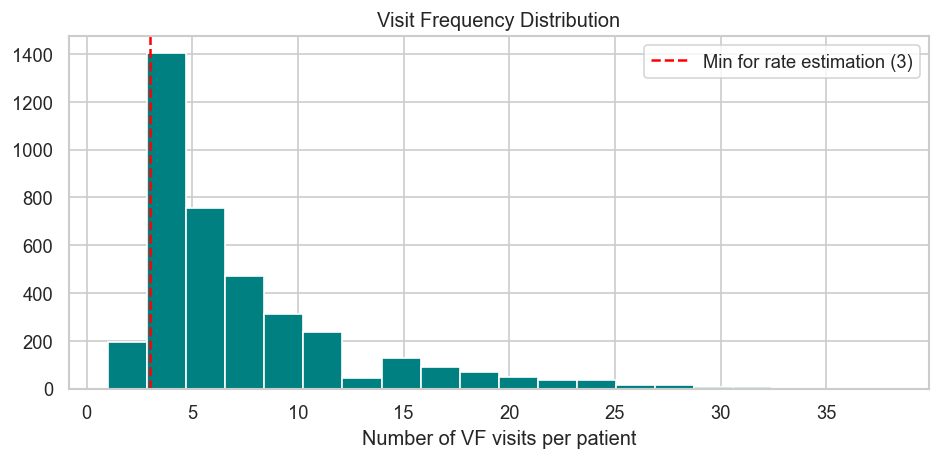

In [8]:
pid_col = next((c for c in df.columns if "patient" in c.lower() or "id" in c.lower()), None)
date_col = next((c for c in df.columns if "date" in c.lower() or "visit" in c.lower()), None)
print(f"Patient ID col: {pid_col} | Date col: {date_col}")

if pid_col:
    visit_counts = df.group_by(pid_col).len().rename({"len": "n_visits"})
    print(f"\nPatients: {visit_counts.height:,}")
    print(f"Visits/patient: mean={visit_counts['n_visits'].mean():.1f}, "
          f"median={visit_counts['n_visits'].median():.0f}, "
          f"max={visit_counts['n_visits'].max()}")
    
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(visit_counts["n_visits"].to_numpy(), bins=20, color="teal", edgecolor="white")
    ax.axvline(3, color="red", ls="--", label="Min for rate estimation (3)")
    ax.set_xlabel("Number of VF visits per patient")
    ax.set_title("Visit Frequency Distribution")
    ax.legend()
    plt.tight_layout()
    plt.show()

Progression rates computed: 3675 patients
MD rate — mean: -25.084 dB/yr | std: 775.521
Fast progressors (< -1 dB/yr): 54.8%


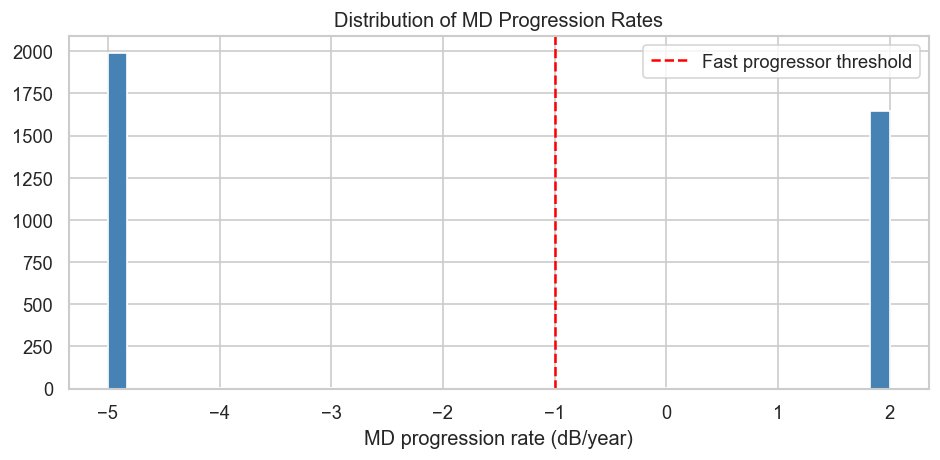

In [9]:
# Compute OLS progression rates for patients with ≥3 visits
def ols_slope(x, y):
    x_mean, y_mean = x.mean(), y.mean()
    num = ((x - x_mean) * (y - y_mean)).sum()
    den = ((x - x_mean) ** 2).sum()
    return num / den if den > 1e-10 else 0.0

if pid_col and date_col and md_col:
    rates = []
    for pid, group in df.group_by(pid_col):
        g = group.sort(date_col)
        if len(g) < 3:
            continue
        try:
            # Parse dates if string
            dates = g[date_col].cast(pl.Date).to_numpy().astype("datetime64[D]")
            times = (dates - dates[0]).astype(float) / 365.25
        except Exception:
            times = np.arange(len(g), dtype=float)
        md_vals = g[md_col].to_numpy()
        rate = ols_slope(times, md_vals)
        rates.append({"patient_id": str(pid[0]), "md_rate": rate, "n_visits": len(g)})
    
    rates_df = pl.DataFrame(rates)
    print(f"Progression rates computed: {len(rates_df)} patients")
    
    md_rates = rates_df["md_rate"].to_numpy()
    print(f"MD rate — mean: {md_rates.mean():.3f} dB/yr | std: {md_rates.std():.3f}")
    print(f"Fast progressors (< -1 dB/yr): {(md_rates < -1).mean()*100:.1f}%")
    
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(np.clip(md_rates, -5, 2), bins=40, color="steelblue", edgecolor="white")
    ax.axvline(-1, color="red", ls="--", label="Fast progressor threshold")
    ax.set_xlabel("MD progression rate (dB/year)")
    ax.set_title("Distribution of MD Progression Rates")
    ax.legend()
    plt.tight_layout()
    plt.savefig("../reports/eda_uwhvf_rates.png", dpi=150, bbox_inches="tight")
    plt.show()

## 5. VF Point-wise Heatmap

VF scalar point columns: 0


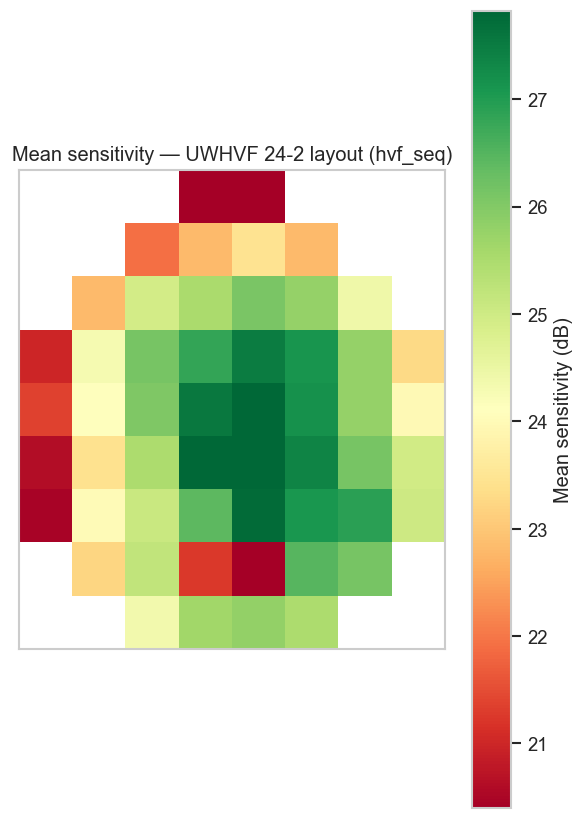

In [10]:
# VF heatmap: 54 scalar columns, or UWHVF list columns hvf_seq / td_seq + coords
vf_cols = [
    c
    for c in df.columns
    if c.startswith("vf_")
    or c.startswith("point_")
    or (c.startswith("td_") and c not in ("td", "td_seq"))
]
print(f"VF scalar point columns: {len(vf_cols)}")


def _nanmean_seq(col_name: str, sentinel: float = 100.0):
    """Mean over visits at each sequence index; untested == sentinel -> NaN."""
    lists = df[col_name].drop_nulls().to_list()
    if not lists:
        return None
    arr = np.stack([np.asarray(s, dtype=np.float64) for s in lists])
    arr = np.where(arr >= sentinel - 1e-6, np.nan, arr)
    return np.nanmean(arr, axis=0)


def _seq_to_grid(values_1d: np.ndarray, coords: list) -> np.ndarray:
    nx = max(c["x"] for c in coords) + 1
    ny = max(c["y"] for c in coords) + 1
    grid = np.full((ny, nx), np.nan, dtype=np.float64)
    for c in coords:
        i = c["index"]
        if i < len(values_1d):
            grid[c["y"], c["x"]] = values_1d[i]
    return grid


coords = None
if (UWHVF_DIR / "alldata.json").exists():
    with open(UWHVF_DIR / "alldata.json") as f:
        coords = json.load(f).get("coords")

if len(vf_cols) == 54:
    vf_mean = df[vf_cols].mean().to_numpy().reshape(1, -1)
    fig, ax = plt.subplots(figsize=(10, 4))
    im = ax.imshow(vf_mean, aspect="auto", cmap="RdYlGn", vmin=-30, vmax=0)
    plt.colorbar(im, ax=ax, label="Mean (dB)")
    ax.set_title("Mean VF — 54 scalar columns")
    ax.set_xlabel("VF point index")
    plt.tight_layout()
    plt.show()
elif coords and "hvf_seq" in df.columns:
    v1d = _nanmean_seq("hvf_seq")
    if v1d is not None:
        grid = _seq_to_grid(v1d, coords)
        lo, hi = np.nanpercentile(v1d, [5, 95])
        fig, ax = plt.subplots(figsize=(5, 7))
        im = ax.imshow(grid, aspect="equal", cmap="RdYlGn", vmin=lo, vmax=hi)
        plt.colorbar(im, ax=ax, label="Mean sensitivity (dB)")
        ax.set_title("Mean sensitivity — UWHVF 24-2 layout (hvf_seq)")
        ax.set_xticks([])
        ax.set_yticks([])
        plt.tight_layout()
        plt.show()
elif coords and "td_seq" in df.columns:
    v1d = _nanmean_seq("td_seq")
    if v1d is not None:
        grid = _seq_to_grid(v1d, coords)
        fig, ax = plt.subplots(figsize=(5, 7))
        im = ax.imshow(grid, aspect="equal", cmap="RdBu_r", vmin=-30, vmax=0)
        plt.colorbar(im, ax=ax, label="Mean TD (dB)")
        ax.set_title("Mean total deviation — UWHVF layout (td_seq)")
        ax.set_xticks([])
        ax.set_yticks([])
        plt.tight_layout()
        plt.show()
else:
    print("No VF grid: need 54 vf_/point_/td_* columns, or hvf_seq/td_seq plus alldata.json coords.")

## 6. Key Findings

Summarize what we learned from the EDA to inform preprocessing and modeling decisions.

In [11]:
print("=== EDA Summary ===")
print(f"Total VF tests:       {len(df):,}")
if pid_col:
    print(f"Unique patients:      {df[pid_col].n_unique():,}")
if md_col:
    md_arr = df[md_col].drop_nulls().to_numpy()
    print(f"MD range:             [{md_arr.min():.1f}, {md_arr.max():.1f}] dB")
    print(f"Severe loss (MD<-12): {(md_arr < -12).mean()*100:.1f}%")
print("\n→ Next: 03_eda_grape.ipynb for multimodal EDA")
print("→ Then: 04_vf_preprocessing.ipynb to build clean dataset")

=== EDA Summary ===
Total VF tests:       28,943
Unique patients:      3,871
MD range:             [-31.7, 19.3] dB
Severe loss (MD<-12): 15.3%

→ Next: 03_eda_grape.ipynb for multimodal EDA
→ Then: 04_vf_preprocessing.ipynb to build clean dataset
